<a href="https://colab.research.google.com/github/elifnurerdemir/Transformer-Customer-Service-Sentiment-Analysis/blob/main/DI725_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Service Sentiment Analysis with Transformer**

**Section 0:** Setup and Data Loading

In [5]:
#Libaries
!pip install -q transformers datasets wandb accelerate

import pandas as pd
import wandb
import os

In [6]:

# Weights & Biases Initialization
wandb.login()
wandb.init(project="transformer-sentiment-analysis-di725", entity="elifnurerdemir")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elifnurerdemir to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
#Data Loading
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("Datasets loaded successfully!")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Datasets loaded successfully!
Training samples: 970
Testing samples: 30


****Section 1:** Exploratory Data Analysis for the dataset**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [9]:
# Load the dataset
df = pd.read_csv('train.csv')

# Standardize sentiment labels to lowercase
df['customer_sentiment'] = df['customer_sentiment'].str.lower()

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (970, 11)


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


--- Label Counts ---
customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

--- Label Percentages ---
customer_sentiment
neutral     55.876289
negative    42.371134
positive     1.752577
Name: proportion, dtype: float64


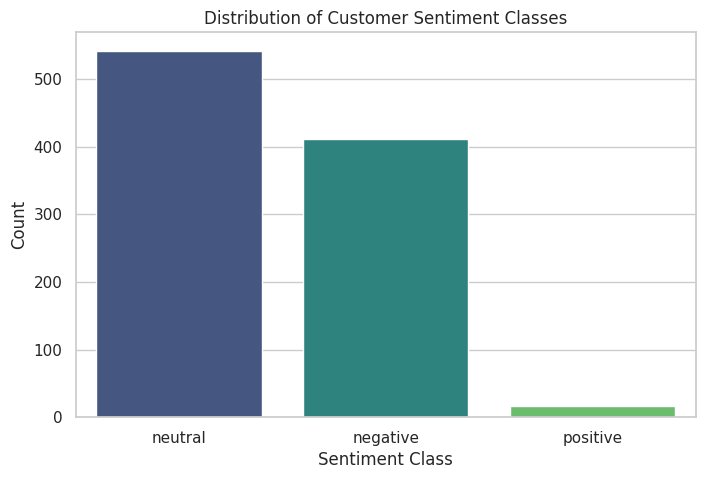

In [14]:
# Print the exact number of labels for each class
print("--- Label Counts ---")
label_counts = df['customer_sentiment'].value_counts()
print(label_counts)

# Calculate percentages
print("\n--- Label Percentages ---")
print(df['customer_sentiment'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='customer_sentiment', data=df, palette='viridis')
plt.title('Distribution of Customer Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

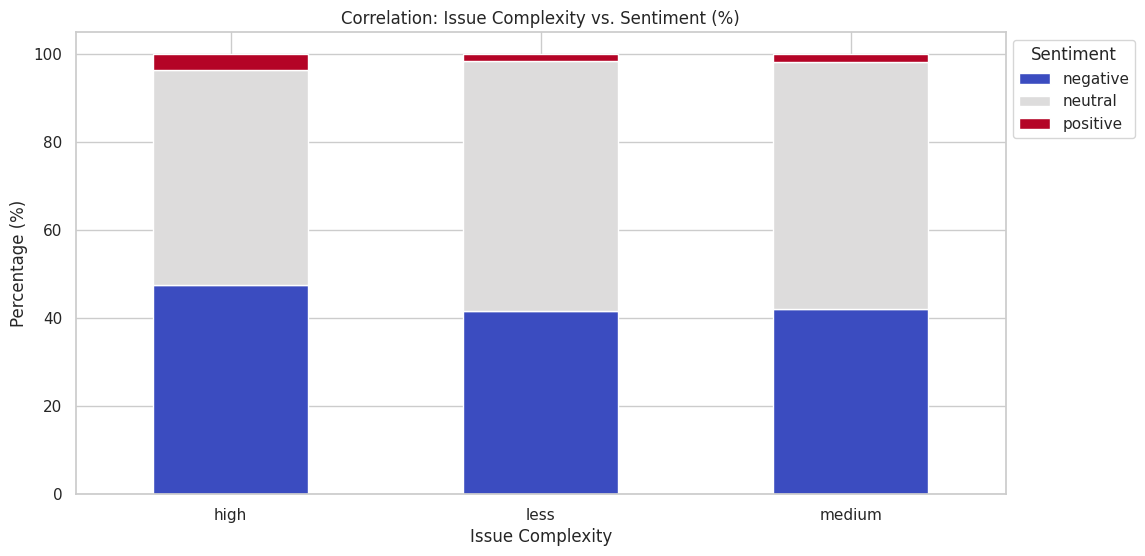

In [10]:
# Analyzing correlation between Issue Complexity and Sentiment
complexity_sentiment = pd.crosstab(df['issue_complexity'], df['customer_sentiment'], normalize='index') * 100

complexity_sentiment.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Correlation: Issue Complexity vs. Sentiment (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('Issue Complexity')
plt.legend(title='Sentiment', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

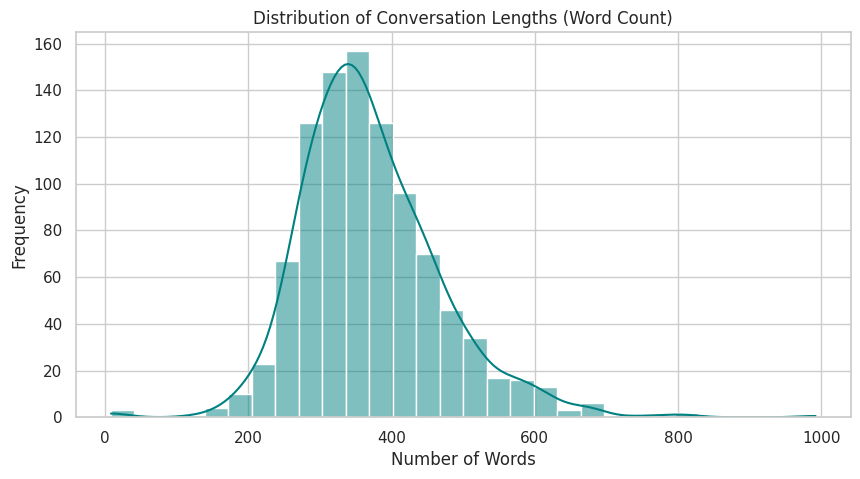

Average Word Count: 370.86
90th Percentile: 494.10


In [11]:
# Word count for each interaction
df['word_count'] = df['conversation'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='teal')
plt.title('Distribution of Conversation Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Average Word Count: {df['word_count'].mean():.2f}")
print(f"90th Percentile: {df['word_count'].quantile(0.90):.2f}")

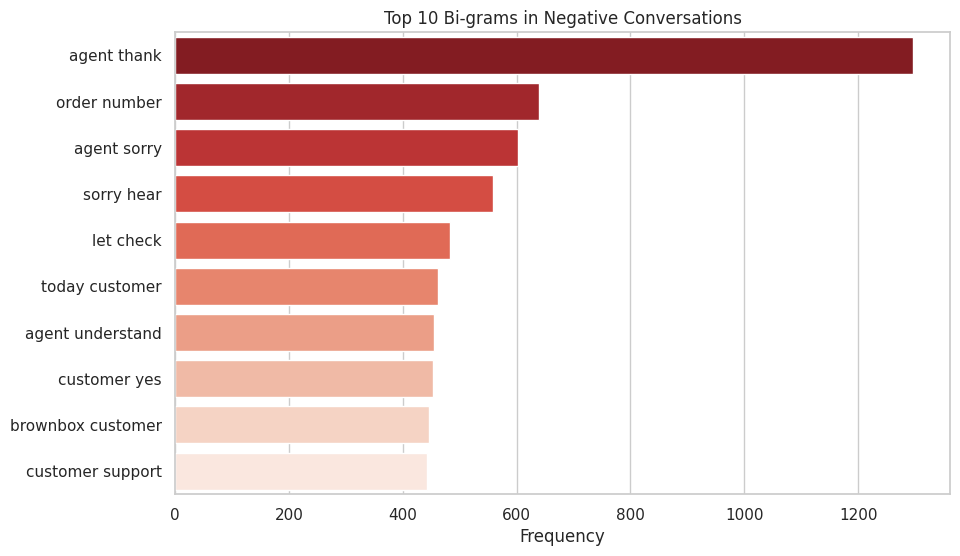

In [12]:
def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# Focus on Negative Sentiment patterns
neg_conversations = df[df['customer_sentiment'] == 'negative']['conversation']
top_bigrams = get_top_ngrams(neg_conversations, n=2)
words, counts = zip(*top_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 10 Bi-grams in Negative Conversations')
plt.xlabel('Frequency')
plt.show()

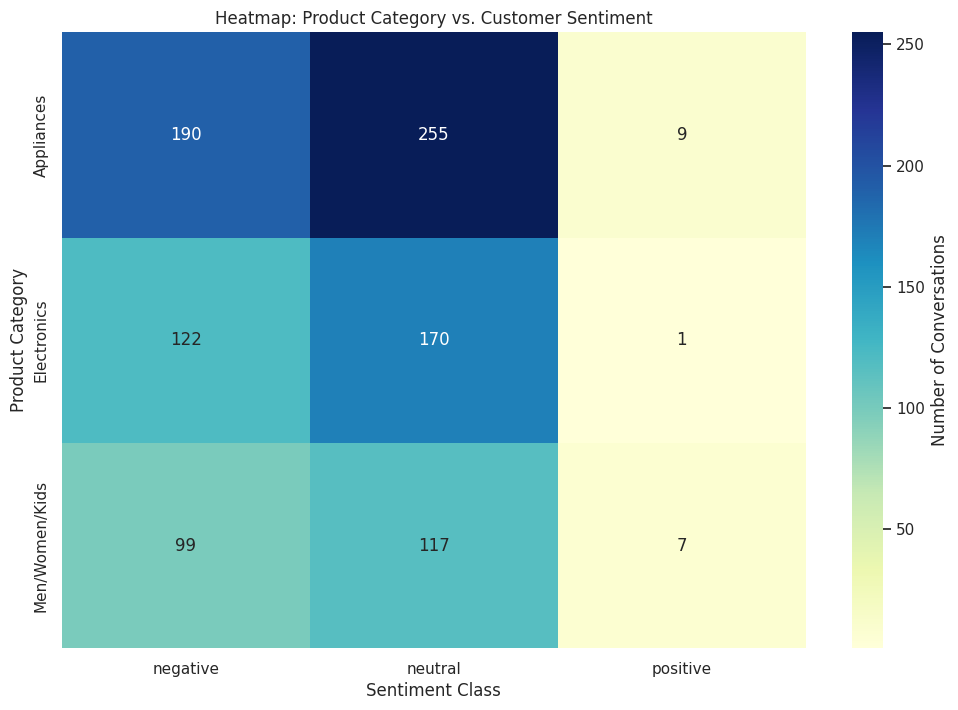

In [15]:
# Create a cross-tabulation of Product Category and Sentiment
heatmap_data = pd.crosstab(df['product_category'], df['customer_sentiment'])

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of Conversations'})
plt.title('Heatmap: Product Category vs. Customer Sentiment')
plt.ylabel('Product Category')
plt.xlabel('Sentiment Class')
plt.show()